Exercise: House Price Prediction using Linear Regression


1. Get dataset - DONE
2. Break data into input & traget features
3. Train test split
4. We will bring our model
5. Train our model on training set
6. make new predictions
7. Compare y_predictions vs y_test to check model performance using:
    - MAE. MSE, RMSE & R2

In [14]:
# 1. Get dataset - DONE

import pandas as pd

df = pd.read_csv("House Price Prediction Dataset.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [19]:
# 2. Break data into input & target features

X = df.drop("Price", axis=1)

X = X.drop("Id", axis=1)

y = df["Price"]

X = pd.get_dummies(X, drop_first=True)

X.head()


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,False,False,False,False,False,False,False
1,4272,5,4,3,1958,False,False,False,False,False,False,False
2,3592,2,2,3,1938,False,False,False,False,True,False,False
3,966,4,2,2,1902,False,True,False,True,False,False,True
4,4926,1,4,2,1975,False,False,False,True,False,False,True


In [20]:
# 3. Train test split

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# 4. We will bring our model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [22]:
# 5. Train our model on training set

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ -0.58, 76.78, -9662.25,...,-12941.04, 4073.27, 2373.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Area','Bedrooms','Bathrooms',...,'Condition_Good','Condition_Poor', 'Garage_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.785e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [23]:
# 6. make new predictions

y_prediction = model.predict(X_test)

In [39]:
#7. Compare y_predictions vs y_test to check model performance using:
#    - a.MAE. b.MSE, c.RMSE & d.R2


#from sklearn.metrics import mean_absolute_error
#from sklearn.metrics import mean_squared_error
#from sklearn.metrics import r2_score
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             root_mean_squared_error,
                             r2_score)
 
import numpy as np

predictions = model.predict(X_test)

#a)MAE (Mean Absolute Error)
MAE = mean_absolute_error(y_test,predictions)
print("Error in our model - MAE:", MAE)

# b) MSE (Mean Squared Error)
MSE = mean_squared_error(y_test,predictions)
print("Error in our model - MSE:", MSE)

# c) RMSE (Root Mean Squared Error)
RMSE = np.sqrt(MSE)
print("Error in our model - RMSE:", RMSE)

# d) R² Score (Coefficient of Determination)
R2 = r2_score(y_test,predictions)
print("Error in our model - R2:", R2)

Error in our model - MAE: 243241.97758826384
Error in our model - MSE: 78321466146.0328
Error in our model - RMSE: 279859.72583784326
Error in our model - R2: -0.006717808430749761


In [54]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             root_mean_squared_error,
                             r2_score)


# 1. Load Dataset
df = pd.read_csv("House Price Prediction Dataset.csv")


# 2. Separate X and Y
X = df.drop(["Price"],axis=1)
y = df["Price"]


# Convert categorical columns
X = pd.get_dummies(X,drop_first=True)


# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# 4. Create Model
model = LinearRegression()


# 5. Train Model
model.fit(X_train,y_train)


# 6. Prediction
predictions = model.predict(X_test)


# 7. Evaluation
MAE = mean_absolute_error(y_test,predictions)
print(f"Error in our model - MAE: {MAE:.2f}")

MSE = mean_squared_error(y_test,predictions)
print(f"Error in our model - MSE: {MSE:.2f}")

RMSE = np.sqrt(MSE)
print(f"Error in our model - RMSE: {RMSE:.2f}")

R2 = r2_score(y_test,predictions)
print(f"Error in our model - R2: {R2:.2f}")


Error in our model - MAE: 242867.45
Error in our model - MSE: 78279764120.86
Error in our model - RMSE: 279785.21
Error in our model - R2: -0.01


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score
 
data = df
 
X = data[['Area','Bedrooms','Bathrooms','Floors']]
 
y = data['Price']
 
X_train,X_test,y_train,y_test = train_test_split( X, y , test_size = 0.2, random_state =42)
 
model = LinearRegression()
 
model.fit(X_train,y_train)
 
predictions1 = model.predict(X_test)
 
error1 = mean_absolute_error(y_test, predictions1)
print("Error mae in our model =  ",error1 * 100, "%")
 
error2 = mean_squared_error(y_test, predictions1)
print("Error mse in our model =  ",error2)
 
error3 = root_mean_squared_error(y_test, predictions1)
print("Error rmse in our model =  ",error3)
 
error4 =r2_score(y_test, predictions1)
print("Error r2 in our model =  ",error4 * 100, "%")
 
house1 = [[1360,5,4,3]]
price = model.predict(house1)
print(f"The prediction price of house 1 = {house1} is ----> price = {price}")

Error mae in our model =   24439969.77248102 %
Error mse in our model =   78701869220.47183
Error rmse in our model =   280538.53428802226
Error r2 in our model =   -1.1607381727367194 %
The prediction price of house 1 = [[1360, 5, 4, 3]] is ----> price = [545719.17373901]


C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Load Dataset
df = pd.read_csv("UK House Price Prediction 2015 to 2024.csv")
df.head()

# 2. Separate X and Y
X = df.drop("price", axis=1)
y = df["price"]

# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 4. Create Model
model = LinearRegression()

# Identify categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns
categorical_features

# Convert text into numbers (One Hot Encoding)
preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

# Combine Encoding + Model
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", model)])

# 5. Train Model
pipeline.fit(X_train, y_train)

# 6. Prediction
predictions = pipeline.fit(X_train, y_train)

# Compare Prediction vs Actual
comparison = pd.DataFrame({"Actual Price": y_test,"Predicted Price": predictions})

# 7. Evaluation
MAE = mean_absolute_error(y_test, predictions)
print(f"MAE: {MAE:.2f}")


C:\Users\User\AppData\Local\Temp\ipykernel_2244\2235610326.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


TypeError: Expected sequence or array-like, got <class 'sklearn.pipeline.Pipeline'>

In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score)


# 1. Load Dataset
df = pd.read_csv("UK House Price Prediction 2015 to 2024.csv")


# 2. Separate X and Y
X = df.drop(["price"],axis=1)
y = df["price"]


# Convert categorical columns
#X = pd.get_dummies(X,drop_first=True)


# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# 4. Create Model
model = LinearRegression()


# 5. Train Model
model.fit(X_train,y_train)


# 6. Prediction
predictions = model.predict(X_test)


# 7. Evaluation
MAE = mean_absolute_error(y_test,predictions)
print(f"Error in our model - MAE: {MAE:.2f}")

MSE = mean_squared_error(y_test,predictions)
print(f"Error in our model - MSE: {MSE:.2f}")

RMSE = np.sqrt(MSE)
print(f"Error in our model - RMSE: {RMSE:.2f}")

R2 = r2_score(y_test,predictions)
print(f"Error in our model - R2: {R2:.2f}")


ValueError: could not convert string to float: '2018-12-12'

In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df = pd.read_csv("UK House Price Prediction 2015 to 2024.csv")

y = df["price"]
X = df.drop("price", axis=1)

categorical_features = X.select_dtypes(include=["object"]).columns
categorical_features

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()

from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", model)])

pipeline.fit(X_train, y_train)

y_predictions = pipeline.predict(X_test)

comparison = pd.DataFrame({"Actual Price": y_test,"Predicted Price": y_predictions})
comparison.head(10)

MAE = mean_absolute_error(y_test, y_predictions)
print(f"MAE: {MAE:.2f}")

MSE = mean_squared_error(y_test, y_predictions)
print(f"MSE: {MSE:.2f}")

RMSE = np.sqrt(MSE)
print(f"RMSE: {RMSE:.2f}")

R2 = r2_score(y_test, y_predictions)
print(f"R2 Score: {R2:.2f}")

C:\Users\User\AppData\Local\Temp\ipykernel_2244\3778279742.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


MAE: 257246.09
MSE: 684068259391.16
RMSE: 827084.19
R2 Score: -0.90


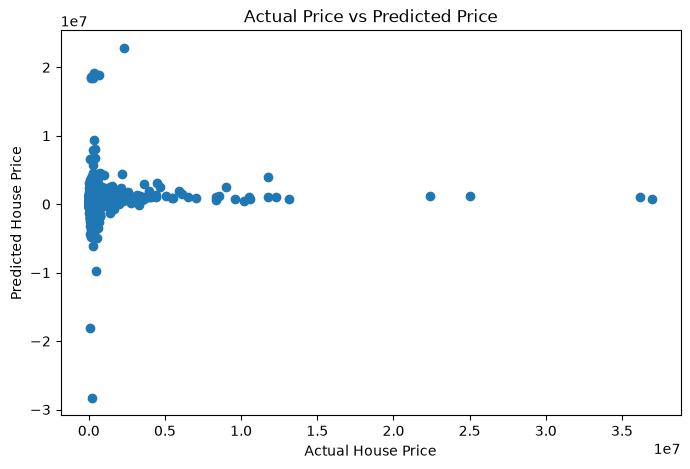

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_predictions)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual Price vs Predicted Price")

plt.show()